ID           8083.000000
red_axis       -1.079578
blue_axis            NaN
EW JADES     1308.626255
Name: 22, dtype: float64


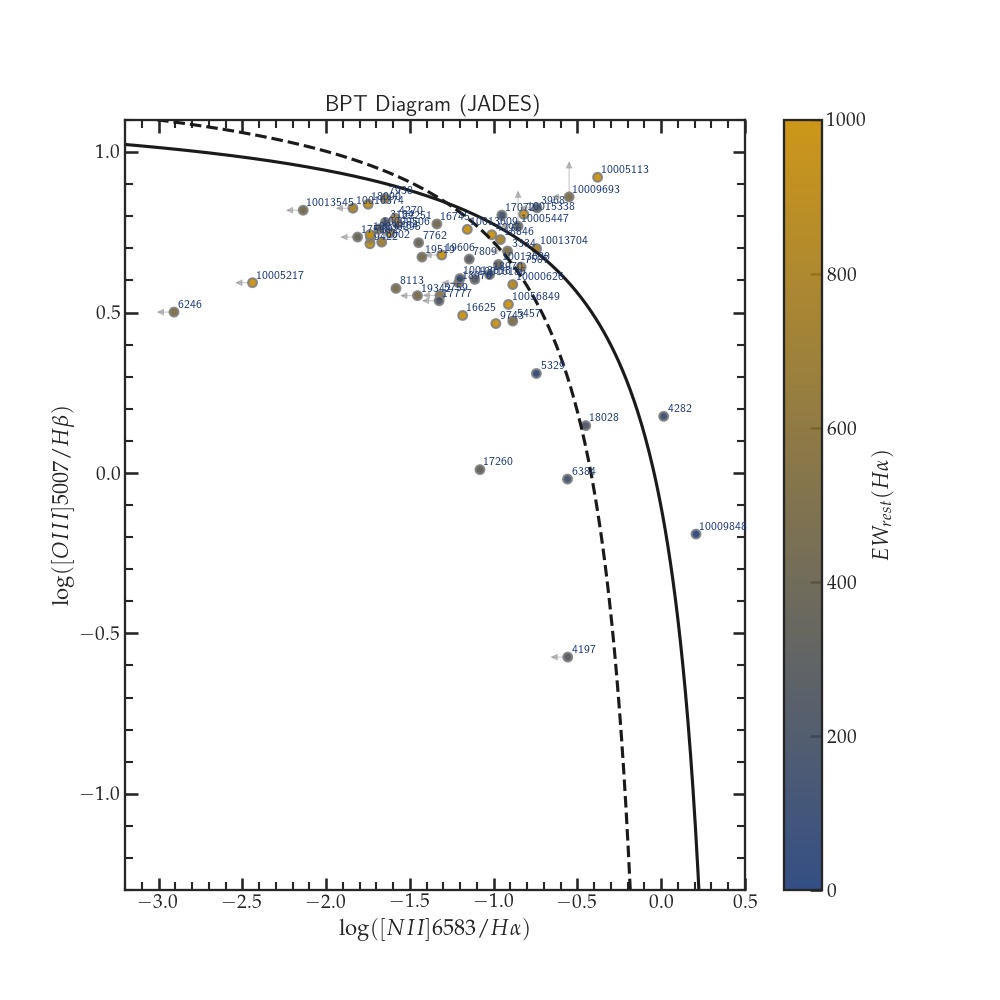

In [ ]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

%matplotlib widget
#================= Plot Settings =================#
# Latex rendering
plt.rc('font', **{'family': 'serif', 'serif': ['palatino']}) #Helvetica
plt.rc('text', usetex=True)
plt.rc('font', weight='bold')

# --- Cosmology palette (normalized RGB) ---
COSMO_COLORS = {
    "deep_blue": (30/255, 60/255, 120/255),
    "warm_gold": (200/255, 140/255, 0/255),
    "dark_teal": (0/255, 130/255, 90/255),
    "soft_crimson": (150/255, 40/255, 40/255),
    "cool_gray": (120/255, 120/255, 120/255),
    }

sns.set_theme(
    style="ticks",
    context='talk',
    rc={
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
        "axes.grid": True,
    })

sns.set_palette([
    COSMO_COLORS["deep_blue"],
    "black",
    COSMO_COLORS["warm_gold"],
    COSMO_COLORS["cool_gray"],
    COSMO_COLORS["dark_teal"],
    COSMO_COLORS["soft_crimson"],
    ])

#General Settings
plt.rc('axes', titlesize=16)     # fontsize of the axes title
plt.rc('axes', labelsize=16)     # fontsize of the x and y labels
plt.rc('axes', linewidth=1.65 )   # width of the frame
plt.rc('xtick', labelsize=14)    # fontsize of the tick labels
plt.rc('ytick', labelsize=14)    # fontsize of the tick labels
plt.rc('legend', fontsize=12)    # legend fontsize
plt.rc('font', size=16)          # controls default text sizes


def compute_axes(source='MAST', filter='G235M', save=False, show=True):
    #================= File Reading =================#
    # Read the TSV file
    df_all = pd.read_csv('./Output_data/Line_fluxes_all_filters.tsv', sep='\t')
    equivalent_widths = pd.read_csv('./Equivalent_width_data.tsv', sep='\t')
    

    if source == 'MAST':
        suffix = f'MAST {filter}'
    elif source == 'JADES':
        suffix = f'JADES {filter}'


    # Create a sub dataframe with ID, redshift, and all columns containing the suffix
    cols = [col for col in df_all.columns if suffix in col]
    df_sub = df_all[['ID', 'redshift'] + cols].copy()
    
    #Define arrays for each axis on the BPT diagram
    blue_axis = np.log10(df_sub[f'Flux ([OIII]5007) {suffix}'] / df_sub[f'Flux (Hb 4861) {suffix}'])
    red_axis = np.log10(df_sub[f'Flux ([NII]6583) {suffix}'] / df_sub[f'Flux (Ha 6563) {suffix}'])
    
    result = {
        'ID': df_sub['ID'],
        'redshift': df_sub['redshift'],
        'blue_axis': blue_axis,
        'red_axis': red_axis,
        'NII': df_sub[f'Flux ([NII]6583) {suffix}'],
        'NII_err': df_sub[f'F_err([NII]6583) {suffix}'],
        'Hb': df_sub[f'Flux (Hb 4861) {suffix}'],
        'Hb_err': df_sub[f'F_err(Hb 4861) {suffix}'],
        'EW MAST': -1*equivalent_widths['EW(Ha) MAST'],
        'EW JADES': -1*equivalent_widths['EW(Ha) JADES']
    }
    
    return pd.DataFrame(result)
#====================================================================#
#====================================================================#

def plt_bpt(source='JADES', arrows=True, labels=True, save=False, show=True, index=60):

    df_235 = compute_axes(source=source, filter='G235M')
    df_395 = compute_axes(source=source, filter='G395M')
    df_395H = compute_axes(source=source, filter='G395H')

    
    cols = ['blue_axis', 'red_axis', 'NII', 'NII_err', 'Hb', 'Hb_err']
    keys = ['ID', 'redshift', f'EW {source}']
    
    # Keep only rows common to all three dataframes 
    base = (
        df_235[keys].merge(df_395[keys], on=keys, how='inner').merge(df_395H[keys], on=keys, how='inner')
    )
    
    # Align each dataframe to the common keys
    a = base.merge(df_235[keys + cols], on=keys, how='left')
    b = base.merge(df_395[keys + cols], on=keys, how='left')
    c = base.merge(df_395H[keys + cols], on=keys, how='left')

    # Start from common ID/redshift
    df_final = base.copy()
    
    # Priority: df_235 -> df_395 -> df_395H -> NaN
    for col in cols:
        df_final[col] = a[col].combine_first(b[col]).combine_first(c[col])

    df_final['red_err'] = df_final['NII'] < df_final['NII_err']
    df_final['blue_err'] = df_final['Hb'] < df_final['Hb_err']


    # Kewley maximum starburst line-
    x_kewly = np.linspace(-3.5, 0.25, 500)
    x_kauff = np.linspace(-3.5, 0., 500)
    y_kewly = 0.61 / (x_kewly - 0.47) + 1.19
    y_kauff = 0.61 / (x_kauff - 0.05) + 1.3

    #=================| plot function |=================# 
    plt.figure(figsize=(10, 10))

    plt.plot(x_kewly, y_kewly, color='k', label='Kewley et al. 2001')
    plt.plot(x_kauff, y_kauff, color='k', linestyle='--', label='Kauffmann+2003')
    
    plt.xlim(-3.2, 0.5)
    plt.ylim(-1.3, 1.1)
    plt.xlabel(r'$\log([NII]6583/H\alpha)$')
    plt.ylabel(r'$\log([OIII]5007/H\beta)$') 
    plt.minorticks_on()
    plt.grid(False)

    xf=df_final['red_axis']
    yf=df_final['blue_axis']

    

    # Custom colormap: gray → red
    gray_red_cmap = LinearSegmentedColormap.from_list(
        'gray_red',
        [COSMO_COLORS['deep_blue'], COSMO_COLORS['warm_gold']]
    )
    
    scatter = plt.scatter(
        xf, yf,
        s=40,
        c=df_final['EW MAST'] if source == 'MAST' else df_final['EW JADES'],
        cmap=gray_red_cmap,
        edgecolor='grey',
        alpha=0.9,
        vmin=0,
        vmax=1000
    )

    cbar = plt.colorbar(scatter)
    cbar.set_label(f'$EW_{{rest}}(H\\alpha)$')
    plt.title(f'BPT Diagram ({source})')


    if labels:
        for x, y, obj_id in zip(xf, yf, df_final['ID']):
            plt.annotate(
                str(obj_id),
                (x, y),
                textcoords="offset points",
                xytext=(3, 3),
                ha="left",
                fontsize=8,
                color=COSMO_COLORS['deep_blue']
            )

    
    
    if arrows:
        for x, y in zip(xf[df_final['red_err']], yf[df_final['red_err']] ):
            plt.annotate(
                '',
                xy=(x - 0.12, y),
                xytext=(x, y),
                arrowprops=dict(arrowstyle='-|>', color=COSMO_COLORS['cool_gray'], alpha=0.4, lw=.8, mutation_scale=10),
                va='center'
            )

        
        for x, y in zip(xf[df_final['blue_err']], yf[df_final['blue_err']] ):
            plt.annotate(
                '',
                xy=(x, y+0.12),
                xytext=(x, y),
                arrowprops=dict(arrowstyle='-|>', color=COSMO_COLORS['cool_gray'], alpha=0.4, lw=.8, mutation_scale=10),
                va='center'
            )
    
    
    if save:
        plt.savefig('bpt_jades_all_objects.pdf', bbox_inches='tight')

    
    print(df_final[['ID', 'red_axis', 'blue_axis', f'EW {source}']].iloc[22])
    plt.show()

    



plt_bpt(labels=True, arrows=True, show=True, index=23)

ID           8113.000000
red_axis       -1.582993
blue_axis       0.575098
EW JADES      486.364530
Name: 21, dtype: float64


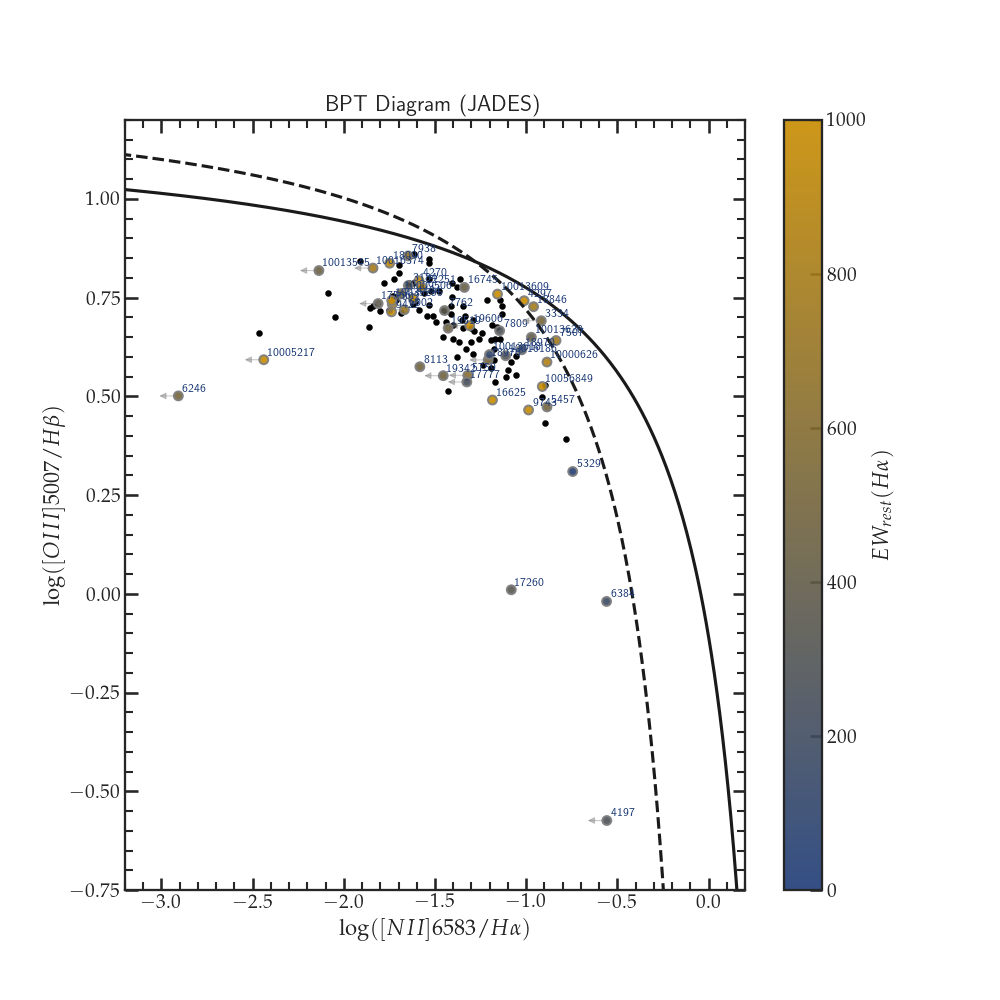

In [35]:
def main():
    exclude_ids = {3968, 4282, 9452, 17072, 18028, 10001587, 10001892, 10009848, 10005113, 10005447, 10009693, 10013704, 10015338}

    df_jades = get_bpt_dataframe('JADES')

    df_jades_filtered = df_jades[~df_jades['ID'].isin(exclude_ids)].reset_index(drop=True)


    plot_bpt_df(df_jades_filtered, 'JADES')
    plt.savefig('Output_data/bpt_jades_HII_candidates.pdf', bbox_inches='tight')



def get_bpt_dataframe(source):
    df_235 = compute_axes(source=source, filter='G235M')
    df_395 = compute_axes(source=source, filter='G395M')
    df_395H = compute_axes(source=source, filter='G395H')

    keys = ['ID', 'redshift', f'EW {source}']
    cols = ['blue_axis', 'red_axis', 'NII', 'NII_err', 'Hb', 'Hb_err']

    base = (
        df_235[keys].merge(df_395[keys], on=keys, how='inner')
        .merge(df_395H[keys], on=keys, how='inner')
    )

    a = base.merge(df_235[keys + cols], on=keys, how='left')
    b = base.merge(df_395[keys + cols], on=keys, how='left')
    c = base.merge(df_395H[keys + cols], on=keys, how='left')

    df_final = base.copy()
    for col in cols:
        df_final[col] = a[col].combine_first(b[col]).combine_first(c[col])

    df_final['red_err'] = df_final['NII'] < df_final['NII_err']
    df_final['blue_err'] = df_final['Hb'] < df_final['Hb_err']
    return df_final

def plot_bpt_df(df_final, source, labels=True, arrows=True):
    x_kewly = np.linspace(-3.5, 0.25, 500)
    x_kauff = np.linspace(-3.5, 0.0, 500)
    y_kewly = 0.61 / (x_kewly - 0.47) + 1.19
    y_kauff = 0.61 / (x_kauff - 0.05) + 1.3

    plt.figure(figsize=(10, 10))
    plt.plot(x_kewly, y_kewly, color='k', label='Kewley et al. 2001')
    plt.plot(x_kauff, y_kauff, color='k', linestyle='--', label='Kauffmann+2003')

    plt.xlim(-3.2, 0.2)
    plt.ylim(-0.75, 1.2)
    plt.xlabel(r'$\log([NII]6583/H\alpha)$')
    plt.ylabel(r'$\log([OIII]5007/H\beta)$')
    plt.minorticks_on()
    plt.grid(False)

    gray_red_cmap = LinearSegmentedColormap.from_list(
        'gray_red',
        [COSMO_COLORS['deep_blue'], COSMO_COLORS['warm_gold']]
    )

    # plot all points as unfilled markers
    plt.scatter(
        df_final['red_axis'],
        df_final['blue_axis'],
        s=40,
        facecolors='none',
        edgecolors='grey',
        alpha=0.7,
        linewidths=0.8
    )
    
    localsample = pd.read_csv('./Output_data/local_sample.tsv', sep='\t')
    sampĺe_red = localsample['red_axis']
    sample_blue = localsample['blue_axis']


    plt.scatter(
        sampĺe_red,
        sample_blue,
        color='black',
        s=10,
        edgecolor='black',
        alpha=1
    )


    # overlay only points with EW values using the color axis
    ew_mask = df_final[f'EW {source}'].notna()
    scatter = plt.scatter(
        df_final.loc[ew_mask, 'red_axis'],
        df_final.loc[ew_mask, 'blue_axis'],
        s=40,
        c=df_final.loc[ew_mask, f'EW {source}'],
        cmap=gray_red_cmap,
        edgecolors='grey',
        alpha=0.9,
        vmin=0,
        vmax=1000
    )

    cbar = plt.colorbar(scatter)
    cbar.set_label(f'$EW_{{rest}}(H\\alpha)$')
    plt.title(f'BPT Diagram ({source})')

    if labels:
        for x, y, obj_id in zip(df_final['red_axis'], df_final['blue_axis'], df_final['ID']):
            plt.annotate(
                str(obj_id),
                (x, y),
                textcoords="offset points",
                xytext=(3, 3),
                ha="left",
                fontsize=8,
                color=COSMO_COLORS['deep_blue']
            )

    if arrows:
        for x, y in zip(df_final.loc[df_final['red_err'], 'red_axis'],
                        df_final.loc[df_final['red_err'], 'blue_axis']):
            plt.annotate(
                '',
                xy=(x - 0.12, y),
                xytext=(x, y),
                arrowprops=dict(
                    arrowstyle='-|>',
                    color=COSMO_COLORS['cool_gray'],
                    alpha=0.4,
                    lw=0.8,
                    mutation_scale=10
                ),
                va='center'
            )

        for x, y in zip(df_final.loc[df_final['blue_err'], 'red_axis'],
                        df_final.loc[df_final['blue_err'], 'blue_axis']):
            plt.annotate(
                '',
                xy=(x, y + 0.10),
                xytext=(x, y),
                arrowprops=dict(
                    arrowstyle='-|>',
                    color=COSMO_COLORS['cool_gray'],
                    alpha=0.4,
                    lw=0.8,
                    mutation_scale=10
                ),
                va='center'
            )

    print(df_final[['ID', 'red_axis', 'blue_axis', f'EW {source}']].iloc[21])

    
    plt.show()

main()

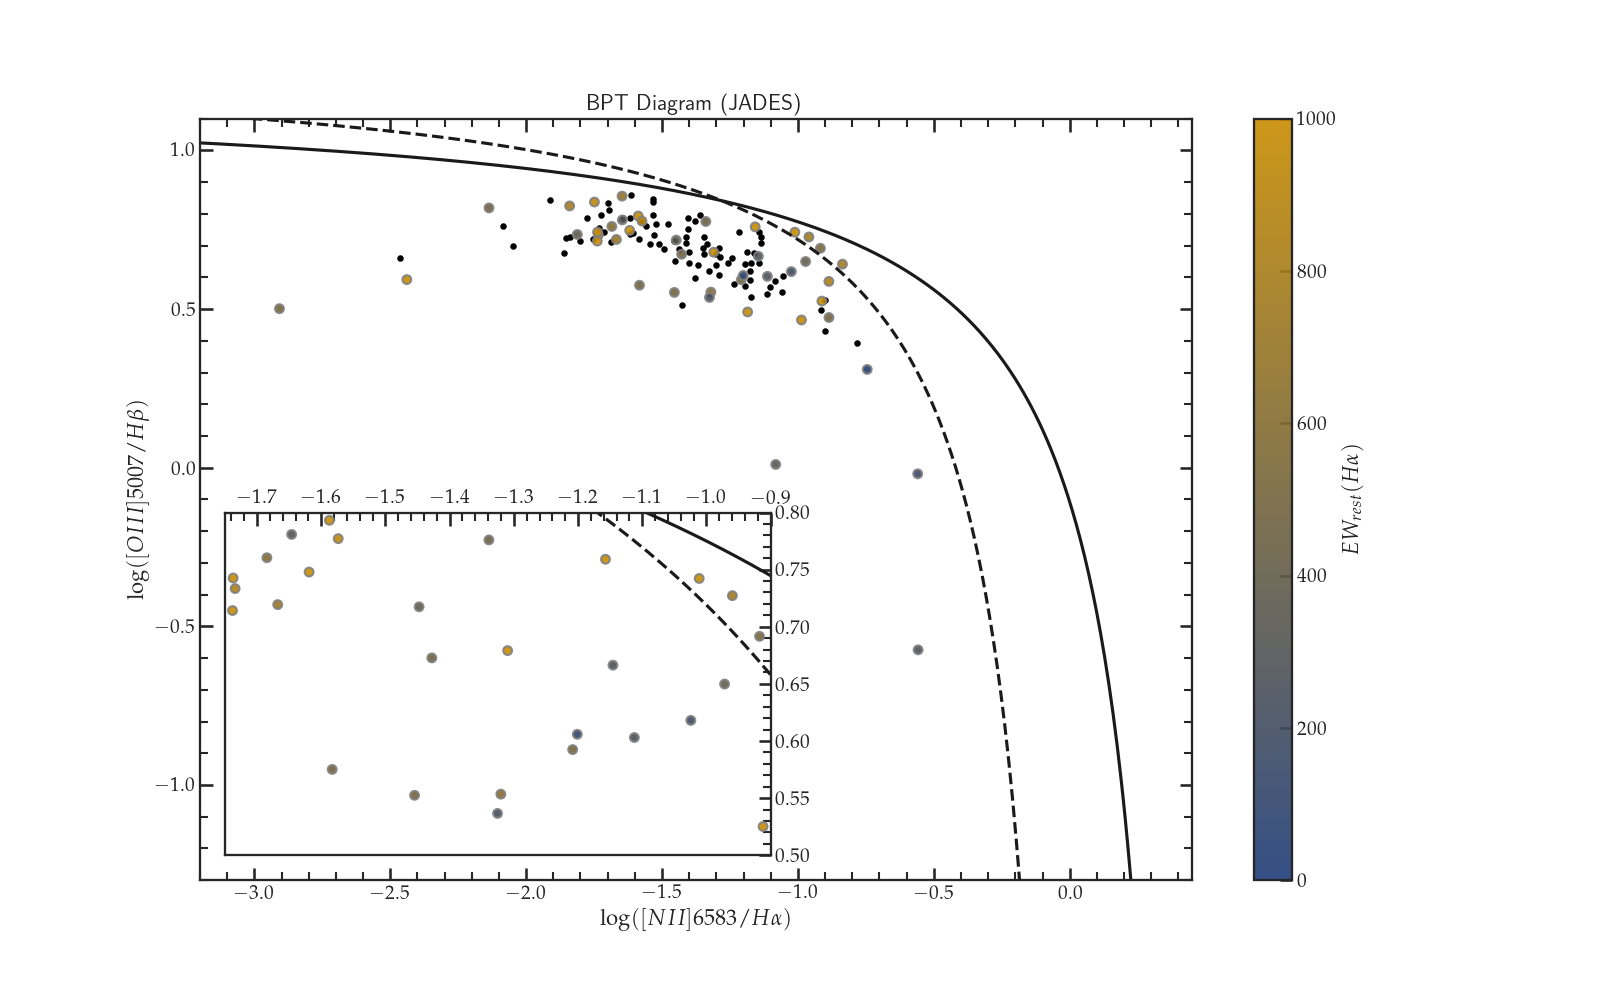

In [34]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

exclude_ids = {3968, 4282, 9452, 17072, 18028, 10001587, 10001892, 10009848, 10005113, 10005447, 10009693, 10013704, 10015338}

df_jades = get_bpt_dataframe('JADES')

df_jades_filtered = df_jades[~df_jades['ID'].isin(exclude_ids)].reset_index(drop=True)


# Create the main plot
x_kewly = np.linspace(-3.5, 0.25, 500)
x_kauff = np.linspace(-3.5, 0., 500)
y_kewly = 0.61 / (x_kewly - 0.47) + 1.19
y_kauff = 0.61 / (x_kauff - 0.05) + 1.3

fig, ax = plt.subplots(figsize=(16, 9.89))

ax.plot(x_kewly, y_kewly, color='k', label='Kewley et al. 2001')
ax.plot(x_kauff, y_kauff, color='k', linestyle='--', label='Kauffmann+2003')

ax.set_xlim(-3.2, 0.45)
ax.set_ylim(-1.3, 1.1)
ax.set_xlabel(r'$\log([NII]6583/H\alpha)$')
ax.set_ylabel(r'$\log([OIII]5007/H\beta)$')
ax.minorticks_on()
ax.grid(False)

gray_red_cmap = LinearSegmentedColormap.from_list(
    'gray_red',
    [COSMO_COLORS['deep_blue'], COSMO_COLORS['warm_gold']]
)

localsample = pd.read_csv('./Output_data/local_sample.tsv', sep='\t')
sampĺe_red = localsample['red_axis']
sample_blue = localsample['blue_axis']


local_scatter = ax.scatter(
    sampĺe_red,
    sample_blue,
    color='black',
    s=10,
    edgecolor='black',
    alpha=1
)



scatter = ax.scatter(
    df_jades_filtered['red_axis'],
    df_jades_filtered['blue_axis'],
    s=40,
    c=df_jades_filtered['EW JADES'],
    cmap=gray_red_cmap,
    edgecolor='grey',
    alpha=0.9,
    vmin=0,
    vmax=1000
)


cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label(r'$EW_{rest}(H\alpha)$')
ax.set_title('BPT Diagram (JADES)')




# Create inset
axins = inset_axes(ax, width="55%", height="45%", loc='lower left', borderpad=1.5)
axins.plot(x_kewly, y_kewly, color='k')
axins.plot(x_kauff, y_kauff, color='k', linestyle='--')
axins.scatter(
    df_jades_filtered['red_axis'],
    df_jades_filtered['blue_axis'],
    s=40,
    c=df_jades_filtered['EW JADES'],
    cmap=gray_red_cmap,
    edgecolor='grey',
    alpha=0.9,
    vmin=0,
    vmax=1000
)
axins.set_xlim(-1.75, -.9)
axins.set_ylim(0.5, 0.8)
axins.minorticks_on()
axins.grid(False)
axins.xaxis.tick_top()
axins.yaxis.tick_right()


"""
# Add labels to main plot
for x, y, obj_id in zip(df_jades_filtered['red_axis'], df_jades_filtered['blue_axis'], df_jades_filtered['ID']):
    ax.annotate(
        str(obj_id),
        (x, y),
        textcoords="offset points",
        xytext=(3, 3),
        ha="left",
        fontsize=8,
        color=COSMO_COLORS['deep_blue']
    )

# Add labels to inset
for x, y, obj_id in zip(df_jades_filtered['red_axis'], df_jades_filtered['blue_axis'], df_jades_filtered['ID']):
    if -2 <= x <= -1 and 0 <= y <= 0.8:
        axins.annotate(
            str(obj_id),
            (x, y),
            textcoords="offset points",
            xytext=(3, 3),
            ha="left",
            fontsize=8,
            color=COSMO_COLORS['deep_blue']
        )
"""

plt.show()

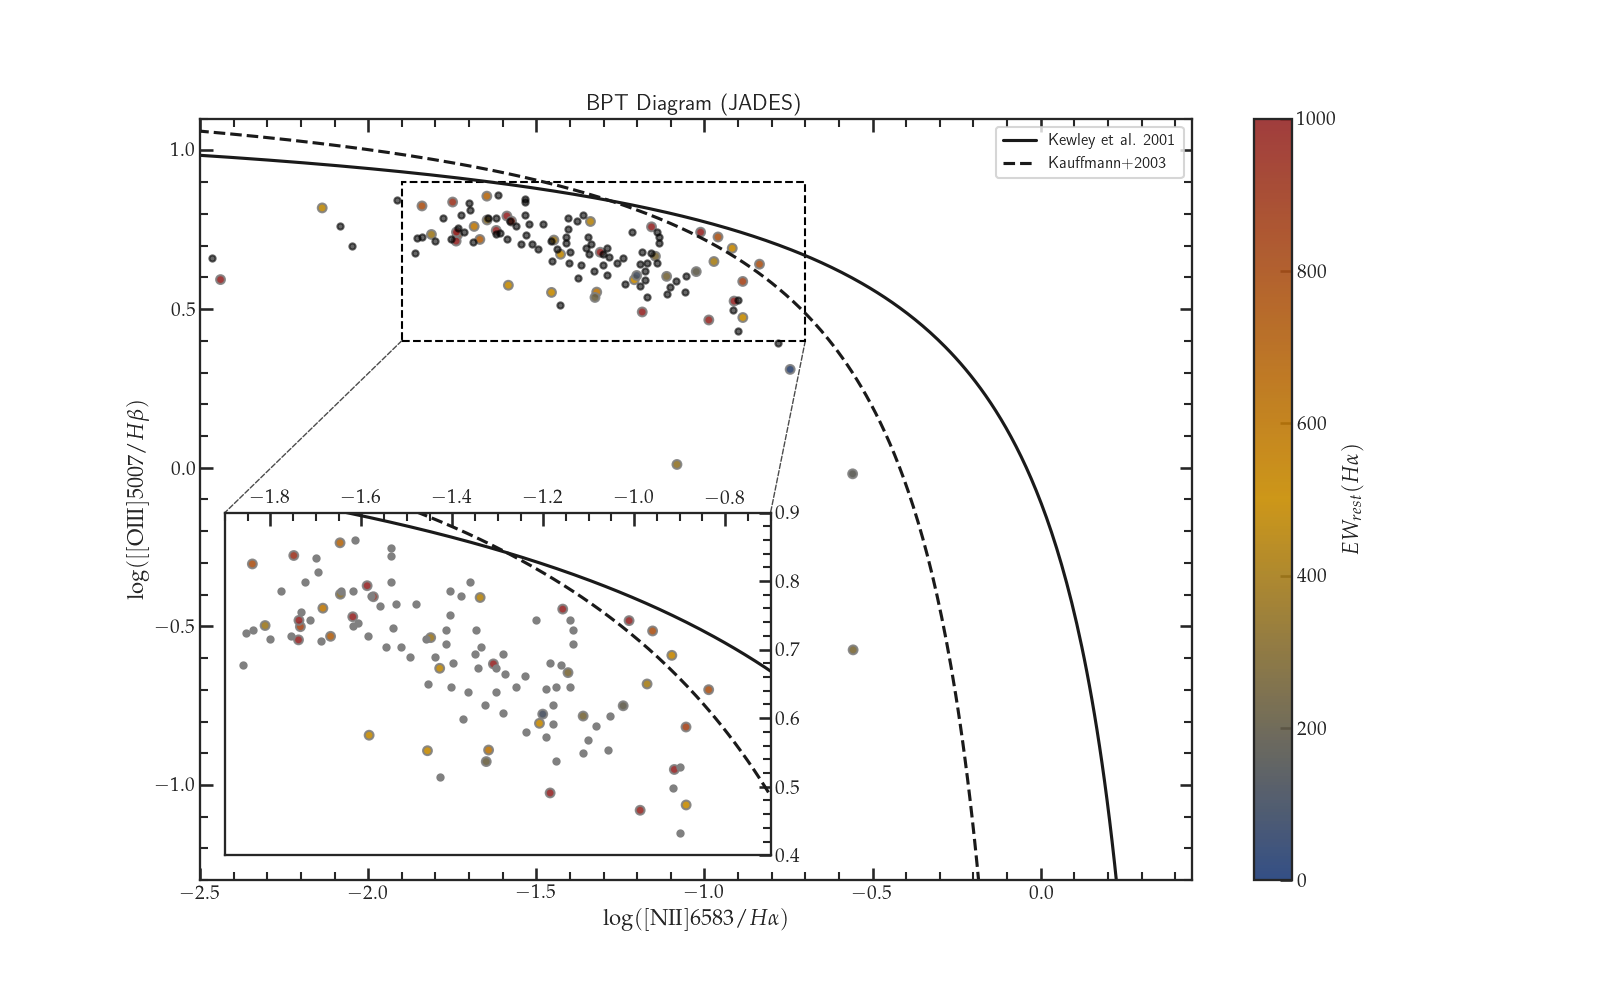

In [39]:
from matplotlib.patches import Rectangle
from matplotlib.patches import ConnectionPatch

# rectangle region matching the inset limits
x0, x1 = -1.9, -0.7
y0, y1 = 0.4, 0.9

fig, ax = plt.subplots(figsize=(16, 9.89))

ax.plot(x_kewly, y_kewly, color='k', label='Kewley et al. 2001')
ax.plot(x_kauff, y_kauff, color='k', linestyle='--', label='Kauffmann+2003')

ax.set_xlim(-2.5, 0.45)
ax.set_ylim(-1.3, 1.1)
ax.set_xlabel(r'$\log([\mathrm{NII}]6583/H \alpha)$')
ax.set_ylabel(r'$\log([\mathrm{[OIII}]5007/H\beta)$')
ax.minorticks_on()
ax.grid(False)
ax.legend()

gray_red_cmap = LinearSegmentedColormap.from_list(
    'gray_red',
    [COSMO_COLORS['deep_blue'], COSMO_COLORS['warm_gold'], COSMO_COLORS['soft_crimson']]
)


scatter = ax.scatter(
    df_jades_filtered['red_axis'],
    df_jades_filtered['blue_axis'],
    s=40,
    c=df_jades_filtered['EW JADES'],
    cmap=gray_red_cmap,
    edgecolor='grey',
    alpha=0.9,
    vmin=0,
    vmax=1000
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label(r'$EW_{rest}(H\alpha)$')
ax.set_title('BPT Diagram (JADES)')

localsample = pd.read_csv('./Output_data/local_sample.tsv', sep='\t')
sampĺe_red = localsample['red_axis']
sample_blue = localsample['blue_axis']


local_scatter = ax.scatter(
    sampĺe_red,
    sample_blue,
    color='black',
    s=20,
    edgecolor='black',
    alpha=0.6
)


# add rectangle on the main plot
rect = Rectangle(
    (x0, y0),
    x1 - x0,
    y1 - y0,
    linewidth=1.5,
    edgecolor='black',
    linestyle='--',
    fill=False
)
ax.add_patch(rect)

axins = inset_axes(ax, width="55%", height="45%", loc='lower left', borderpad=1.5)
axins.plot(x_kewly, y_kewly, color='k')
axins.plot(x_kauff, y_kauff, color='k', linestyle='--')
axins.scatter(
    df_jades_filtered['red_axis'],
    df_jades_filtered['blue_axis'],
    s=40,
    c=df_jades_filtered['EW JADES'],
    cmap=gray_red_cmap,
    edgecolor='grey',
    alpha=0.9,
    vmin=0,
    vmax=1000
)
axins.scatter(
    sampĺe_red,
    sample_blue,
    color='grey',
    s=20,
    edgecolor='grey',
    alpha=1
)
axins.set_xlim(x0, x1)
axins.set_ylim(y0, y1)
axins.minorticks_on()
axins.grid(False)
axins.xaxis.tick_top()
axins.yaxis.tick_right()




"""
for x, y, obj_id in zip(df_jades_filtered['red_axis'], df_jades_filtered['blue_axis'], df_jades_filtered['ID']):
    ax.annotate(
        str(obj_id),
        (x, y),
        textcoords="offset points",
        xytext=(3, 3),
        ha="left",
        fontsize=8,
        color=COSMO_COLORS['deep_blue']
    )

for x, y, obj_id in zip(df_jades_filtered['red_axis'], df_jades_filtered['blue_axis'], df_jades_filtered['ID']):
    if x0 <= x <= x1 and y0 <= y <= y1:
        axins.annotate(
            str(obj_id),
            (x, y),
            textcoords="offset points",
            xytext=(3, 3),
            ha="left",
            fontsize=8,
            color=COSMO_COLORS['deep_blue']
        )
"""
connector1 = ConnectionPatch(
    xyA=(x0, y0),
    coordsA=ax.transData,
    xyB=(0, 1),
    coordsB=axins.transAxes,
    arrowstyle='-',
    linestyle='--',
    linewidth=1,
    color='black',
    alpha=0.7
)
connector2 = ConnectionPatch(
    xyA=(x1, y0),
    coordsA=ax.transData,
    xyB=(1, 1),
    coordsB=axins.transAxes,
    arrowstyle='-',
    linestyle='--',
    linewidth=1,
    color='black',
    alpha=0.7
)
ax.add_artist(connector1)
ax.add_artist(connector2)




plt.show()

BPT for only HII candidates, all JADES objects

In [5]:

def plt_bpt_HII_JADES(source='JADES', arrows=True, labels=True, save=False, show=True, index=60):

    df_235 = compute_axes(source=source, filter='G235M')
    df_395 = compute_axes(source=source, filter='G395M')
    df_395H = compute_axes(source=source, filter='G395H')

    
    cols = ['blue_axis', 'red_axis', 'NII', 'NII_err', 'Hb', 'Hb_err']
    keys = ['ID', 'redshift', f'EW {source}']
    
    # Keep only rows common to all three dataframes 
    base = (
        df_235[keys].merge(df_395[keys], on=keys, how='inner').merge(df_395H[keys], on=keys, how='inner')
    )
    
    # Align each dataframe to the common keys
    a = base.merge(df_235[keys + cols], on=keys, how='left')
    b = base.merge(df_395[keys + cols], on=keys, how='left')
    c = base.merge(df_395H[keys + cols], on=keys, how='left')

    # Start from common ID/redshift
    df_final = base.copy()
    
    # Priority: df_235 -> df_395 -> df_395H -> NaN
    for col in cols:
        df_final[col] = a[col].combine_first(b[col]).combine_first(c[col])

    df_final['red_err'] = df_final['NII'] < df_final['NII_err']
    df_final['blue_err'] = df_final['Hb'] < df_final['Hb_err']


    # Kewley maximum starburst line-
    x_kewly = np.linspace(-2.0, 0.25, 500)
    x_kauff = np.linspace(-2.0, 0., 500)
    y_kewly = 0.61 / (x_kewly - 0.47) + 1.19
    y_kauff = 0.61 / (x_kauff - 0.05) + 1.3

    #=================| plot function |=================# 
    plt.figure(figsize=(10, 10))

    plt.plot(x_kewly, y_kewly, color='k', label='Kewley et al. 2001')
    plt.plot(x_kauff, y_kauff, color='k', linestyle='--', label='Kauffmann+2003')
    
    plt.xlim(-2, 0.5)
    plt.ylim(-1.3, 1.1)
    plt.xlabel(r'$\log([NII]6583/H\alpha)$')
    plt.ylabel(r'$\log([OIII]5007/H\beta)$') 
    plt.minorticks_on()
    plt.grid(False)

    xf=df_final['red_axis']
    yf=df_final['blue_axis']

    

    # Custom colormap: gray → red
    gray_red_cmap = LinearSegmentedColormap.from_list(
        'gray_red',
        [COSMO_COLORS['deep_blue'], COSMO_COLORS['warm_gold']]
    )
    
    scatter = plt.scatter(
        xf, yf,
        s=40,
        c=df_final['EW MAST'] if source == 'MAST' else df_final['EW JADES'],
        cmap=gray_red_cmap,
        edgecolor='grey',
        alpha=0.9,
        vmin=0,
        vmax=1000
    )

    cbar = plt.colorbar(scatter)
    cbar.set_label(f'$EW_{{rest}}(H\\alpha)$')
    plt.title(f'BPT Diagram ({source})')


    if labels:
        for x, y, obj_id in zip(xf, yf, df_final['ID']):
            plt.annotate(
                str(obj_id),
                (x, y),
                textcoords="offset points",
                xytext=(3, 3),
                ha="left",
                fontsize=8,
                color=COSMO_COLORS['deep_blue']
            )

    
    
    if arrows:
        for x, y in zip(xf[df_final['red_err']], yf[df_final['red_err']] ):
            plt.annotate(
                '',
                xy=(x - 0.12, y),
                xytext=(x, y),
                arrowprops=dict(arrowstyle='-|>', color=COSMO_COLORS['cool_gray'], alpha=0.4, lw=.8, mutation_scale=10),
                va='center'
            )

        
        for x, y in zip(xf[df_final['blue_err']], yf[df_final['blue_err']] ):
            plt.annotate(
                '',
                xy=(x, y+0.12),
                xytext=(x, y),
                arrowprops=dict(arrowstyle='-|>', color=COSMO_COLORS['cool_gray'], alpha=0.4, lw=.8, mutation_scale=10),
                va='center'
            )
    
    
    if save:
        plt.savefig('bpt_only_HII_jades.pdf', bbox_inches='tight')

    
    
    plt.show()

    



ID           8113.000000
red_axis       -2.105459
blue_axis       0.565159
EW MAST       478.207740
Name: 18, dtype: float64


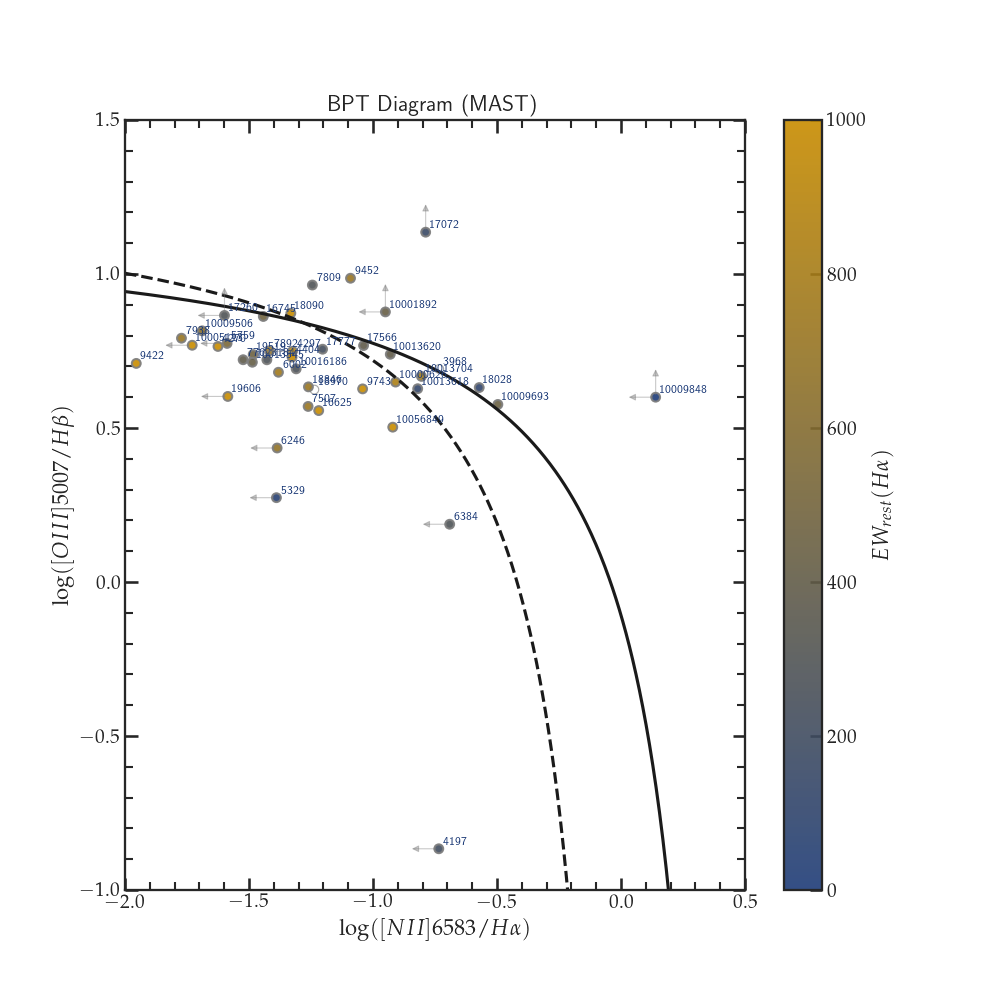

ID           8113.000000
red_axis       -1.582993
blue_axis       0.575098
EW JADES      486.364530
Name: 18, dtype: float64


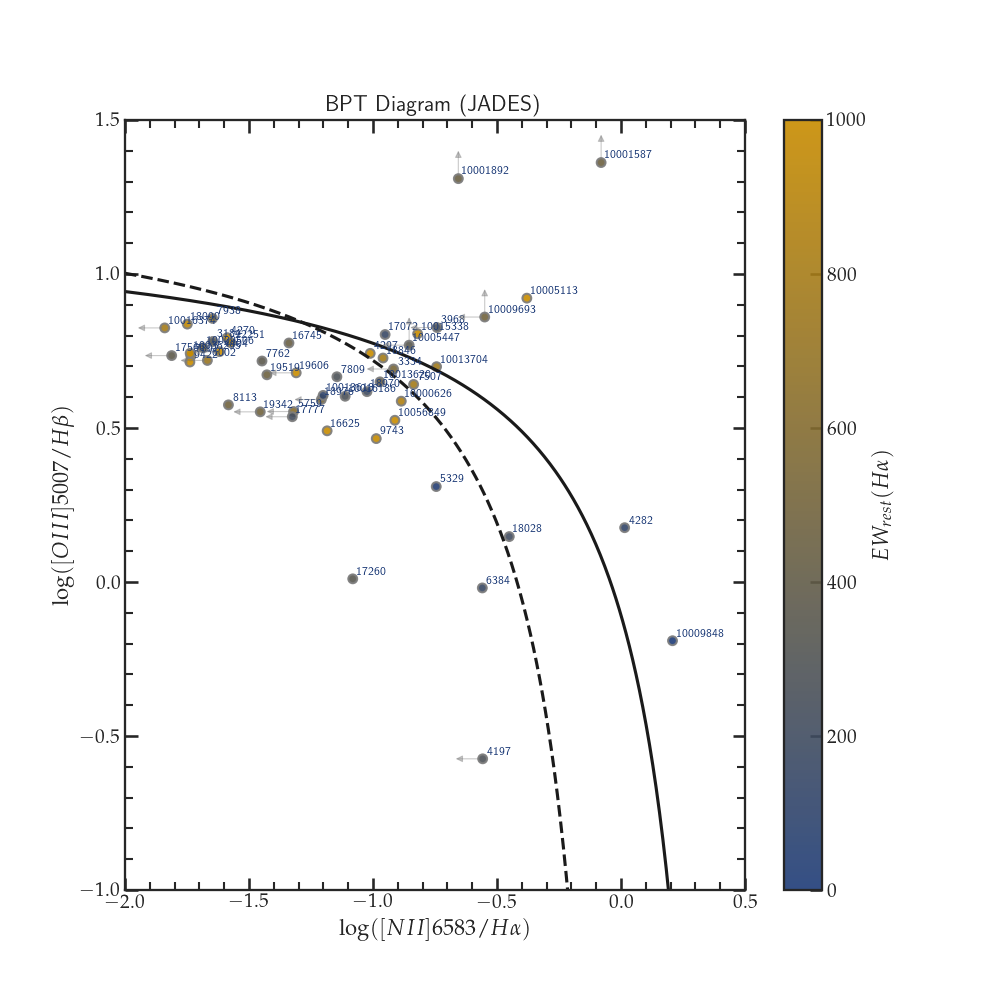

In [6]:
def main():

    df_mast = get_bpt_dataframe('MAST')
    df_jades = get_bpt_dataframe('JADES')

    common_ids = (
        set(df_mast.loc[df_mast[['red_axis', 'blue_axis']].notna().all(axis=1), 'ID']) &
        set(df_jades.loc[df_jades[['red_axis', 'blue_axis']].notna().all(axis=1), 'ID'])
    )

    df_mast_common = df_mast[df_mast['ID'].isin(common_ids)].reset_index(drop=True)
    df_jades_common = df_jades[df_jades['ID'].isin(common_ids)].reset_index(drop=True)

    plot_bpt_df(df_mast_common, 'MAST')
    plot_bpt_df(df_jades_common, 'JADES')

def compute_axes(source='MAST', filter='G235M', save=False, show=True):
    #================= File Reading =================#
    # Read the TSV file
    df_all = pd.read_csv('./Output_data/Line_fluxes_all_filters.tsv', sep='\t')
    equivalent_widths = pd.read_csv('./Equivalent_width_data.tsv', sep='\t')

    if source == 'MAST':
        suffix = f'MAST {filter}'
    elif source == 'JADES':
        suffix = f'JADES {filter}'


    # Create a sub dataframe with ID, redshift, and all columns containing the suffix
    cols = [col for col in df_all.columns if suffix in col]
    df_sub = df_all[['ID', 'redshift'] + cols].copy()
    
    #Define arrays for each axis on the BPT diagram
    blue_axis = np.log10(df_sub[f'Flux ([OIII]5007) {suffix}'] / df_sub[f'Flux (Hb 4861) {suffix}'])
    red_axis = np.log10(df_sub[f'Flux ([NII]6583) {suffix}'] / df_sub[f'Flux (Ha 6563) {suffix}'])
    
    result = {
        'ID': df_sub['ID'],
        'redshift': df_sub['redshift'],
        'blue_axis': blue_axis,
        'red_axis': red_axis,
        'NII': df_sub[f'Flux ([NII]6583) {suffix}'],
        'NII_err': df_sub[f'F_err([NII]6583) {suffix}'],
        'Hb': df_sub[f'Flux (Hb 4861) {suffix}'],
        'Hb_err': df_sub[f'F_err(Hb 4861) {suffix}'],
        'EW MAST': -1*equivalent_widths['EW(Ha) MAST'],
        'EW JADES': -1*equivalent_widths['EW(Ha) JADES']
    }
    
    return pd.DataFrame(result)
#====================================================================#
#====================================================================#


def get_bpt_dataframe(source):
    df_235 = compute_axes(source=source, filter='G235M')
    df_395 = compute_axes(source=source, filter='G395M')
    df_395H = compute_axes(source=source, filter='G395H')

    keys = ['ID', 'redshift', f'EW {source}']
    cols = ['blue_axis', 'red_axis', 'NII', 'NII_err', 'Hb', 'Hb_err']

    base = (
        df_235[keys].merge(df_395[keys], on=keys, how='inner')
        .merge(df_395H[keys], on=keys, how='inner')
    )

    a = base.merge(df_235[keys + cols], on=keys, how='left')
    b = base.merge(df_395[keys + cols], on=keys, how='left')
    c = base.merge(df_395H[keys + cols], on=keys, how='left')

    df_final = base.copy()
    for col in cols:
        df_final[col] = a[col].combine_first(b[col]).combine_first(c[col])

    df_final['red_err'] = df_final['NII'] < df_final['NII_err']
    df_final['blue_err'] = df_final['Hb'] < df_final['Hb_err']
    return df_final

def plot_bpt_df(df_final, source, labels=True, arrows=True):
    x_kewly = np.linspace(-2.0, 0.25, 500)
    x_kauff = np.linspace(-2.0, 0.0, 500)
    y_kewly = 0.61 / (x_kewly - 0.47) + 1.19
    y_kauff = 0.61 / (x_kauff - 0.05) + 1.3

    plt.figure(figsize=(10, 10))
    plt.plot(x_kewly, y_kewly, color='k', label='Kewley et al. 2001')
    plt.plot(x_kauff, y_kauff, color='k', linestyle='--', label='Kauffmann+2003')

    plt.xlim(-2, 0.5)
    plt.ylim(-1., 1.5)
    plt.xlabel(r'$\log([NII]6583/H\alpha)$')
    plt.ylabel(r'$\log([OIII]5007/H\beta)$')
    plt.minorticks_on()
    plt.grid(False)

    gray_red_cmap = LinearSegmentedColormap.from_list(
        'gray_red',
        [COSMO_COLORS['deep_blue'], COSMO_COLORS['warm_gold']]
    )

    # plot all points as unfilled markers
    plt.scatter(
        df_final['red_axis'],
        df_final['blue_axis'],
        s=40,
        facecolors='none',
        edgecolors='grey',
        alpha=0.7,
        linewidths=0.8
    )

    # overlay only points with EW values using the color axis
    ew_mask = df_final[f'EW {source}'].notna()
    scatter = plt.scatter(
        df_final.loc[ew_mask, 'red_axis'],
        df_final.loc[ew_mask, 'blue_axis'],
        s=40,
        c=df_final.loc[ew_mask, f'EW {source}'],
        cmap=gray_red_cmap,
        edgecolors='grey',
        alpha=0.9,
        vmin=0,
        vmax=1000
    )

    cbar = plt.colorbar(scatter)
    cbar.set_label(f'$EW_{{rest}}(H\\alpha)$')
    plt.title(f'BPT Diagram ({source})')

    if labels:
        for x, y, obj_id in zip(df_final['red_axis'], df_final['blue_axis'], df_final['ID']):
            plt.annotate(
                str(obj_id),
                (x, y),
                textcoords="offset points",
                xytext=(3, 3),
                ha="left",
                fontsize=8,
                color=COSMO_COLORS['deep_blue']
            )

    if arrows:
        for x, y in zip(df_final.loc[df_final['red_err'], 'red_axis'],
                        df_final.loc[df_final['red_err'], 'blue_axis']):
            plt.annotate(
                '',
                xy=(x - 0.12, y),
                xytext=(x, y),
                arrowprops=dict(
                    arrowstyle='-|>',
                    color=COSMO_COLORS['cool_gray'],
                    alpha=0.4,
                    lw=0.8,
                    mutation_scale=10
                ),
                va='center'
            )

        for x, y in zip(df_final.loc[df_final['blue_err'], 'red_axis'],
                        df_final.loc[df_final['blue_err'], 'blue_axis']):
            plt.annotate(
                '',
                xy=(x, y + 0.10),
                xytext=(x, y),
                arrowprops=dict(
                    arrowstyle='-|>',
                    color=COSMO_COLORS['cool_gray'],
                    alpha=0.4,
                    lw=0.8,
                    mutation_scale=10
                ),
                va='center'
            )

    print(df_final[['ID', 'red_axis', 'blue_axis', f'EW {source}']].iloc[18])
    plt.show()

main()


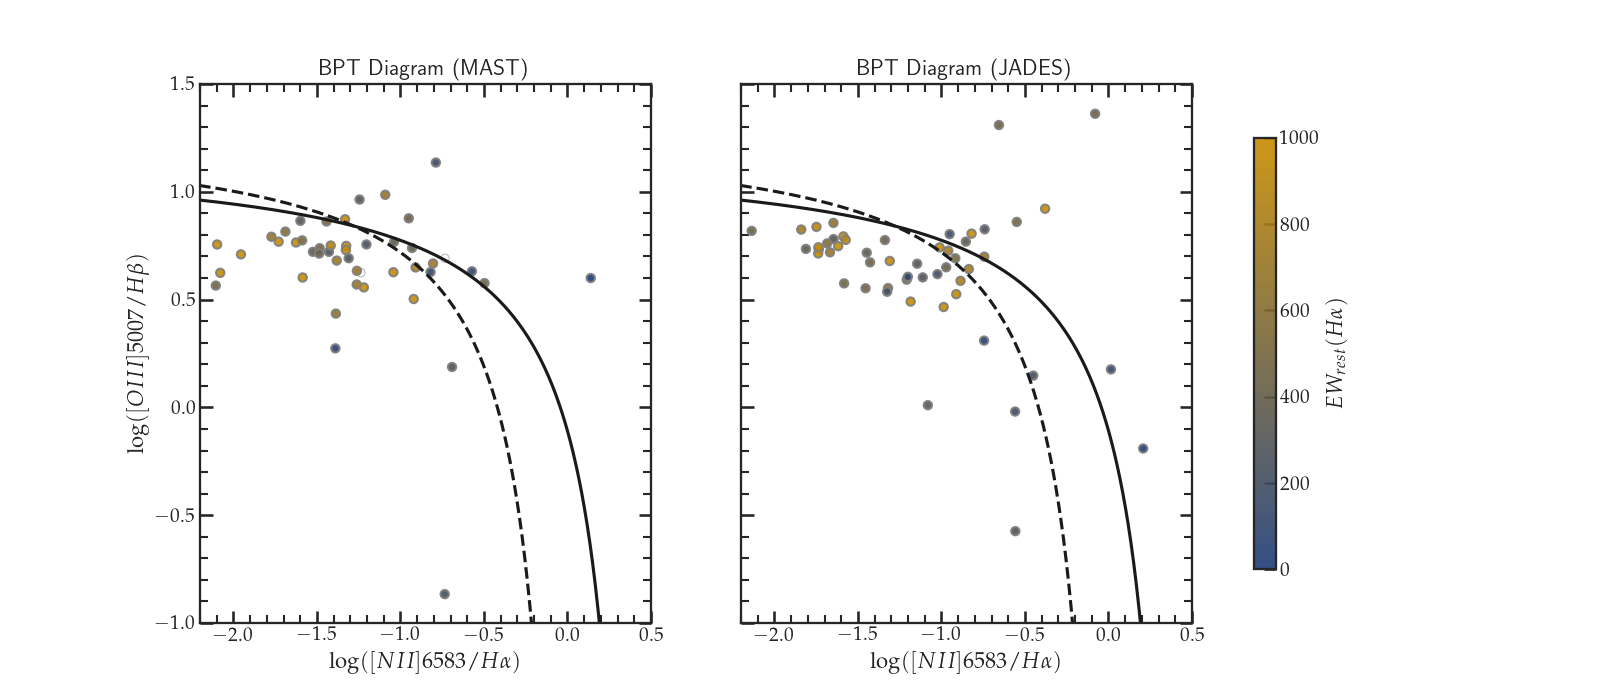

In [7]:
# side-by-side BPT for MAST and JADES with single colorbar
df_mast = get_bpt_dataframe('MAST')
df_jades = get_bpt_dataframe('JADES')

# keep only objects with both axes in both catalogs (as in previous logic)
common_ids = (
    set(df_mast.loc[df_mast[['red_axis', 'blue_axis']].notna().all(axis=1), 'ID']) &
    set(df_jades.loc[df_jades[['red_axis', 'blue_axis']].notna().all(axis=1), 'ID'])
)

df_mast_common = df_mast[df_mast['ID'].isin(common_ids)].reset_index(drop=True)
df_jades_common = df_jades[df_jades['ID'].isin(common_ids)].reset_index(drop=True)

x_kewly = np.linspace(-2.5, 0.25, 500)
x_kauff = np.linspace(-2.5, 0.0, 500)
y_kewly = 0.61 / (x_kewly - 0.47) + 1.19
y_kauff = 0.61 / (x_kauff - 0.05) + 1.3

gray_red_cmap = LinearSegmentedColormap.from_list(
    'gray_red',
    [COSMO_COLORS['deep_blue'], COSMO_COLORS['warm_gold']]
)

vmin, vmax = 0, 1000

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

for ax, df, source, title in zip(axes, [df_mast_common, df_jades_common], ['MAST','JADES'], ['MAST', 'JADES']):
    ax.plot(x_kewly, y_kewly, color='k')
    ax.plot(x_kauff, y_kauff, color='k', linestyle='--')
    ax.set_xlim(-2.2, 0.5)
    ax.set_ylim(-1.0, 1.5)
    ax.set_xlabel(r'$\log([NII]6583/H\alpha)$')
    if ax is axes[0]:
        ax.set_ylabel(r'$\log([OIII]5007/H\beta)$')
    ax.set_title(f'BPT Diagram ({title})')
    ax.grid(False)

    # base unfilled markers
    ax.scatter(df['red_axis'], df['blue_axis'], s=36, facecolors='none', edgecolors='grey', alpha=0.6, linewidths=0.7)
    ax.minorticks_on()

    # overlay colored points (only where EW exists)
    ew_mask = df[f'EW {source}'].notna()
    sc = ax.scatter(
        df.loc[ew_mask, 'red_axis'],
        df.loc[ew_mask, 'blue_axis'],
        s=36,
        c=df.loc[ew_mask, f'EW {source}'],
        cmap=gray_red_cmap,
        edgecolors='grey',
        alpha=0.9,
        vmin=vmin,
        vmax=vmax
    )

    # annotate IDs (optional; keep small)
    """
    for x, y, oid in zip(df['red_axis'], df['blue_axis'], df['ID']):
        ax.annotate(str(oid), (x, y), xytext=(3,3), textcoords='offset points', fontsize=7, color=COSMO_COLORS['deep_blue'])
    """
        
# single colorbar for both axes
cbar = fig.colorbar(sc, ax=axes.ravel().tolist(), shrink=0.8)
cbar.set_label(r'$EW_{rest}(H\alpha)$')

plt.savefig('bpt_mast_jades_comparison.pdf', bbox_inches='tight')

plt.show()

In [8]:
df_mast

,ID,redshift,EW MAST,blue_axis,red_axis,NII,NII_err,Hb,Hb_err,red_err,blue_err
0,3184,3.467620,272.268205,0.721457,-1.427994,0.250107,0.108368,3.031885,0.164560,False,False
1,3334,6.705930,634.471399,1.563504,-0.901830,0.042588,0.059861,0.014340,0.056510,True,True
2,3968,5.768470,NaN,0.691578,-0.733055,0.055256,0.051389,0.141924,0.062922,False,False
3,4197,3.748809,207.586005,-0.866157,-0.734736,0.069541,0.514368,0.211412,0.088350,True,False
4,4270,4.022612,1004.824569,0.764796,-1.625154,0.282024,0.031072,3.408560,0.092160,False,False
...,...,...,...,...,...,...,...,...,...,...,...
58,10015338,5.076272,1409.652301,0.759606,-2.324769,0.011595,0.056876,0.842492,0.211896,True,False
59,10016186,3.927926,266.201862,0.691972,-1.309813,0.123262,0.037078,1.014572,0.061131,False,False
60,10016374,5.503256,745.128453,0.884937,-2.882465,0.001945,0.041846,0.470948,0.062517,True,False
61,10035295,3.588924,1230.259294,0.755658,-2.097319,0.042251,0.066487,1.699393,0.084645,True,False
